<div style="text-align:center;">

# Customer Data Analysis for Business Insights
</div>

<div style="text-align:center;">

<img src = "https://img.freepik.com/premium-photo/3d-business-people-working-data-analytics-monitoring-web-report-dashboard_942243-7824.jpg" width = 1100 height = 300>

</div>

# Project Overview

A mid-sized Indian retail company wants to analyze its customer base to improve
targeted marketing, retain valuable customers, and detect patterns in customer
behavior. You have been hired as a data analyst to clean, process, and analyze the
customer transaction data to generate actionable insights

- Assess customer demographics and transaction behavior
- Clean and prepare the data for analysis
- Conduct RFM (Recency, Frequency, Monetary) analysis
- Visualize key patterns using charts

- Detect incomplete, inconsistent, or duplicate customer records and improve data
quality, if applicable
- Segment customers based on demographics and purchase behavior
- Identify high-value customers using Recency-Frequency-Monetary (RFM) analysis
- Visualize customer distribution across geographies, age groups, or income
brackets
- Generate actionable insights for marketing department

# Analytical Workflow
- ## Step 1:Loading the data

<div style="text-align:center;">

# Customer Master Data Analysis

# Basic Data Inspection

In [4]:
import numpy as np
import pandas as pd 

In [5]:
!pip install openpyxl

In [6]:
df = pd.read_excel(r"C:\Users\Vikash Rao\python 0.7\Customer_Master_Data.xlsx")

In [7]:
df.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [8]:
customers = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Master_Data.csv",encoding = "latin1")
transaction = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Transactions.csv",encoding = "latin1")

# Since we have two datasets, one for customer and one for transactions, we are going to focus on one (Customer) and then transactions


In [9]:
customers.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray DâAlia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [10]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


# Since join date of customers should be datetime, hence we have to convert it

In [11]:
customers["JoinDate"] = pd.to_datetime(customers["JoinDate"], errors = "coerce")

In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


In [10]:
# Our data has no-null entries

In [11]:
customers.describe()

,Age,NumChildren,JoinDate
count,1000.000000,1000.000000,1000
mean,46.471000,1.311000,2022-07-24 01:36:28.800000256
min,18.000000,0.000000,2020-07-29 00:00:00
25%,32.000000,0.000000,2021-07-12 12:00:00
50%,46.000000,1.000000,2022-07-10 12:00:00
75%,60.000000,2.000000,2023-08-05 12:00:00
max,75.000000,4.000000,2024-07-28 00:00:00
std,16.582525,1.190671,NaN


In [12]:
customers.describe(include = "object")

,CustomerID,Name,Email,Gender,City,MaritalStatus
count,1000,1000,1000,1000,1000,1000
unique,1000,993,1000,3,10,4
top,CUST10000,Anahita Buch,pkeer@yahoo.com,Female,Lucknow,Widowed
freq,1,2,1,340,110,280


In [13]:
customers.columns

Index(['CustomerID', 'Name', 'Email', 'Gender', 'Age', 'City', 'MaritalStatus',
       'NumChildren', 'JoinDate'],
      dtype='object')

# Step 2: DATA CLEANING

# Duplicates Inspection

In [14]:
customers.duplicated().sum()

np.int64(0)

# Missing Values

In [15]:
customers.isnull().sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

# Numeric Values Check

In [16]:
customers.describe(include= "int64")

,Age,NumChildren
count,1000.000000,1000.000000
mean,46.471000,1.311000
std,16.582525,1.190671
min,18.000000,0.000000
25%,32.000000,0.000000
50%,46.000000,1.000000
75%,60.000000,2.000000
max,75.000000,4.000000


# Catagorical Values Check

In [17]:
customers.describe(include= "object")

,CustomerID,Name,Email,Gender,City,MaritalStatus
count,1000,1000,1000,1000,1000,1000
unique,1000,993,1000,3,10,4
top,CUST10000,Anahita Buch,pkeer@yahoo.com,Female,Lucknow,Widowed
freq,1,2,1,340,110,280


# Miscelleneous Inspection

In [18]:
customers["Gender"].unique()

array(['Male', 'Female', 'Not Disclosed'], dtype=object)

In [19]:
customers["City"].unique()

array(['Delhi', 'Kolkata', 'Pune', 'Jaipur', 'Hyderabad', 'Ahmedabad',
       'Lucknow', 'Bangalore', 'Chennai', 'Mumbai'], dtype=object)

In [20]:
customers["MaritalStatus"].unique()

array(['Divorced', 'Married', 'Widowed', 'Single'], dtype=object)

In [21]:
customers["Gender"].value_counts()

Gender
Female           340
Male             332
Not Disclosed    328
Name: count, dtype: int64

In [22]:
customers["City"].value_counts()

City
Lucknow      110
Jaipur       109
Hyderabad    104
Ahmedabad    102
Bangalore    102
Delhi         99
Mumbai        99
Pune          93
Kolkata       91
Chennai       91
Name: count, dtype: int64

In [23]:
customers["MaritalStatus"].value_counts()

MaritalStatus
Widowed     280
Divorced    250
Single      246
Married     224
Name: count, dtype: int64

In [24]:
customers["Gender"].nunique()

3

In [25]:
customers["City"].nunique()

10

In [26]:
customers["MaritalStatus"].nunique()

4

In [27]:
# Summary: Data is free of any null or duplicated data. The types of Data are also in order, therefore we can proceed ahead with its transformation required

# Groupby function

In [28]:
customers.groupby('City').size()

City
Ahmedabad    102
Bangalore    102
Chennai       91
Delhi         99
Hyderabad    104
Jaipur       109
Kolkata       91
Lucknow      110
Mumbai        99
Pune          93
dtype: int64

In [29]:
customers.groupby(['Gender']).size()

Gender
Female           340
Male             332
Not Disclosed    328
dtype: int64

In [30]:
customers.groupby(['City','Gender','MaritalStatus']).size().unstack()

MaritalStatus            Divorced  Married  Single  Widowed
City      Gender                                           
Ahmedabad Female               10       10       9        7
          Male                  8        9       5       12
          Not Disclosed         7        6       9       10
Bangalore Female                8        9      11       11
          Male                 10        7       5        5
          Not Disclosed         7        7       9       13
Chennai   Female                3        6       6       10
          Male                 11        8       5        8
          Not Disclosed        10        9       8        7
Delhi     Female                6        4       7        7
          Male                 13       11      10        7
          Not Disclosed         5        8       8       13
Hyderabad Female                8        6       8       10
          Male                 13        5      11       15
          Not Disclosed         8        7       4        9
Jaipur    Female               20        7       8       11
          Male                  6        3       8        5
          Not Disclosed         6       15       7       13
Kolkata   Female               12        6       8        2
          Male                  7        7       7        8
          Not Disclosed        11        5      11        7
Lucknow   Female               12       10       9       15
          Male                  1        9      15        6
          Not Disclosed         8        6       5       14
Mumbai    Female               10        2      13        6
          Male                  5       12      12       10
          Not Disclosed         4        6       6       13
Pune      Female               10        7       6       10
          Male                  7        9       8        9
          Not Disclosed         4        8       8        7

In [31]:
customers.groupby(["City", "Gender", "MaritalStatus"]).size().unstack().sort_index()

MaritalStatus            Divorced  Married  Single  Widowed
City      Gender                                           
Ahmedabad Female               10       10       9        7
          Male                  8        9       5       12
          Not Disclosed         7        6       9       10
Bangalore Female                8        9      11       11
          Male                 10        7       5        5
          Not Disclosed         7        7       9       13
Chennai   Female                3        6       6       10
          Male                 11        8       5        8
          Not Disclosed        10        9       8        7
Delhi     Female                6        4       7        7
          Male                 13       11      10        7
          Not Disclosed         5        8       8       13
Hyderabad Female                8        6       8       10
          Male                 13        5      11       15
          Not Disclosed         8        7       4        9
Jaipur    Female               20        7       8       11
          Male                  6        3       8        5
          Not Disclosed         6       15       7       13
Kolkata   Female               12        6       8        2
          Male                  7        7       7        8
          Not Disclosed        11        5      11        7
Lucknow   Female               12       10       9       15
          Male                  1        9      15        6
          Not Disclosed         8        6       5       14
Mumbai    Female               10        2      13        6
          Male                  5       12      12       10
          Not Disclosed         4        6       6       13
Pune      Female               10        7       6       10
          Male                  7        9       8        9
          Not Disclosed         4        8       8        7

In [32]:
customers.groupby(["City", "Gender","MaritalStatus"]).size().unstack().sort_values(by = ["Married", "Single", "Widowed", "Divorced"])

,MaritalStatus,Divorced,Married,Single,Widowed
City,Gender,,,,
Mumbai,Female,10,2,13,6
Jaipur,Male,6,3,8,5
Delhi,Female,6,4,7,7
Kolkata,Not Disclosed,11,5,11,7
Hyderabad,Male,13,5,11,15
Lucknow,Not Disclosed,8,6,5,14
Chennai,Female,3,6,6,10
Mumbai,Not Disclosed,4,6,6,13
Kolkata,Female,12,6,8,2


# Pivot Table

In [33]:
customers.pivot_table(index = 'City', columns = 'Gender', aggfunc = 'size')

Gender,Female,Male,Not Disclosed
City,,,
Ahmedabad,36,34,32
Bangalore,39,27,36
Chennai,25,32,34
Delhi,24,41,34
Hyderabad,32,44,28
Jaipur,46,22,41
Kolkata,28,29,34
Lucknow,46,31,33
Mumbai,31,39,29


In [34]:
customers["Age"].nunique()

58

In [35]:
customers["Age"].describe()

count    1000.000000
mean       46.471000
std        16.582525
min        18.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        75.000000
Name: Age, dtype: float64

In [36]:
customers["Gender"].value_counts()

Gender
Female           340
Male             332
Not Disclosed    328
Name: count, dtype: int64

<div style="text-align:center;">

# Customer Transaction Data Analysis
</div>

# Basic Inspection

In [37]:
transaction = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Transactions.csv",encoding = "latin1")

In [38]:
transaction.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [39]:
# Converting transcation date to datetime

In [40]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


In [41]:
# Transaction date should be in datetime

In [42]:
transaction["TransactionDate"]= pd.to_datetime(transaction["TransactionDate"] , errors = "coerce")

C:\Users\Vikash Rao\AppData\Local\Temp\ipykernel_9120\34881283.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transaction["TransactionDate"]= pd.to_datetime(transaction["TransactionDate"] , errors = "coerce")


In [43]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   TransactionDate    23050 non-null  datetime64[ns]
 2   TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 540.4+ KB


In [44]:
transaction.describe()

,TransactionDate,TransactionAmount
count,23050,23050.000000
mean,2024-01-22 02:29:03.618221312,1000.138814
min,2020-08-22 00:00:00,3.870000
25%,2023-05-07 00:00:00,482.107500
50%,2024-04-21 00:00:00,844.755000
75%,2024-12-12 00:00:00,1346.795000
max,2025-07-29 00:00:00,6890.190000
std,NaN,703.358978


In [45]:
# Data seems to have outliers

In [46]:
transaction.columns

Index(['CustomerID', 'TransactionDate', 'TransactionAmount'], dtype='object')

# Duplicated Inspection

In [47]:
transaction.duplicated().any()

np.False_

In [48]:
transaction["CustomerID"].nunique()

1000

In [49]:
transaction["CustomerID"].value_counts().sort_index(ascending=True)

CustomerID
CUST10000    23
CUST10001    30
CUST10002    24
CUST10003    25
CUST10004    19
             ..
CUST10995    21
CUST10996    21
CUST10997    20
CUST10998    25
CUST10999    23
Name: count, Length: 1000, dtype: int64

# Missing Value

In [50]:
transaction.isnull().any()

CustomerID           False
TransactionDate      False
TransactionAmount    False
dtype: bool

# Numeric Values Check

In [51]:
transaction.describe(include = "float64")

,TransactionAmount
count,23050.000000
mean,1000.138814
std,703.358978
min,3.870000
25%,482.107500
50%,844.755000
75%,1346.795000
max,6890.190000


# Categorical Values Check

In [52]:
transaction.describe(include ="object")

,CustomerID
count,23050
unique,1000
top,CUST10851
freq,38


# Miscellaneous Check

In [53]:
transaction["CustomerID"].value_counts()

CustomerID
CUST10851    38
CUST10220    38
CUST10201    37
CUST10553    37
CUST10136    37
             ..
CUST10122    12
CUST10605    12
CUST10266    12
CUST10278    10
CUST10729     6
Name: count, Length: 1000, dtype: int64

In [54]:
transaction.groupby(["CustomerID","TransactionAmount"]).max()

TransactionDate
CustomerID TransactionAmount                
CUST10000  92.16                  2024-05-31
           194.10                 2022-10-01
           225.70                 2024-02-25
           467.93                 2025-07-17
           564.00                 2021-05-02
...                                      ...
CUST10999  1619.39                2023-03-15
           1883.60                2025-06-25
           1948.48                2021-11-27
           1993.71                2024-01-17
           2539.21                2023-07-30

[23050 rows x 1 columns]

In [55]:
transaction.groupby(["CustomerID","TransactionAmount"]).mean()

TransactionDate
CustomerID TransactionAmount                
CUST10000  92.16                  2024-05-31
           194.10                 2022-10-01
           225.70                 2024-02-25
           467.93                 2025-07-17
           564.00                 2021-05-02
...                                      ...
CUST10999  1619.39                2023-03-15
           1883.60                2025-06-25
           1948.48                2021-11-27
           1993.71                2024-01-17
           2539.21                2023-07-30

[23050 rows x 1 columns]

In [56]:
transaction.groupby(["CustomerID","TransactionAmount"]).median()

TransactionDate
CustomerID TransactionAmount                
CUST10000  92.16                  2024-05-31
           194.10                 2022-10-01
           225.70                 2024-02-25
           467.93                 2025-07-17
           564.00                 2021-05-02
...                                      ...
CUST10999  1619.39                2023-03-15
           1883.60                2025-06-25
           1948.48                2021-11-27
           1993.71                2024-01-17
           2539.21                2023-07-30

[23050 rows x 1 columns]

# Pivot Table 

In [57]:
transaction.pivot_table(index = "CustomerID", columns = "CustomerID", aggfunc = "count", fill_value = 0)

TransactionAmount                                          \
CustomerID         CUST10000 CUST10001 CUST10002 CUST10003 CUST10004   
CustomerID                                                             
CUST10000                 23         0         0         0         0   
CUST10001                  0        30         0         0         0   
CUST10002                  0         0        24         0         0   
CUST10003                  0         0         0        25         0   
CUST10004                  0         0         0         0        19   
...                      ...       ...       ...       ...       ...   
CUST10995                  0         0         0         0         0   
CUST10996                  0         0         0         0         0   
CUST10997                  0         0         0         0         0   
CUST10998                  0         0         0         0         0   
CUST10999                  0         0         0         0         0   

                                                              ...  \
CustomerID CUST10005 CUST10006 CUST10007 CUST10008 CUST10009  ...   
CustomerID                                                    ...   
CUST10000          0         0         0         0         0  ...   
CUST10001          0         0         0         0         0  ...   
CUST10002          0         0         0         0         0  ...   
CUST10003          0         0         0         0         0  ...   
CUST10004          0         0         0         0         0  ...   
...              ...       ...       ...       ...       ...  ...   
CUST10995          0         0         0         0         0  ...   
CUST10996          0         0         0         0         0  ...   
CUST10997          0         0         0         0         0  ...   
CUST10998          0         0         0         0         0  ...   
CUST10999          0         0         0         0         0  ...   

           TransactionDate                                                    \
CustomerID       CUST10990 CUST10991 CUST10992 CUST10993 CUST10994 CUST10995   
CustomerID                                                                     
CUST10000                0         0         0         0         0         0   
CUST10001                0         0         0         0         0         0   
CUST10002                0         0         0         0         0         0   
CUST10003                0         0         0         0         0         0   
CUST10004                0         0         0         0         0         0   
...                    ...       ...       ...       ...       ...       ...   
CUST10995                0         0         0         0         0        21   
CUST10996                0         0         0         0         0         0   
CUST10997                0         0         0         0         0         0   
CUST10998                0         0         0         0         0         0   
CUST10999                0         0         0         0         0         0   

                                                    
CustomerID CUST10996 CUST10997 CUST10998 CUST10999  
CustomerID                                          
CUST10000          0         0         0         0  
CUST10001          0         0         0         0  
CUST10002          0         0         0         0  
CUST10003          0         0         0         0  
CUST10004          0         0         0         0  
...              ...       ...       ...       ...  
CUST10995          0         0         0         0  
CUST10996         21         0         0         0  
CUST10997          0        20         0         0  
CUST10998          0         0        25         0  
CUST10999          0         0         0        23  

[1000 rows x 2000 columns]

# Step 3: EDA

In [58]:
# Univariate analysis of Customer table

count    1000.000000
mean       46.471000
std        16.582525
min        18.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        75.000000
Name: Age, dtype: float64


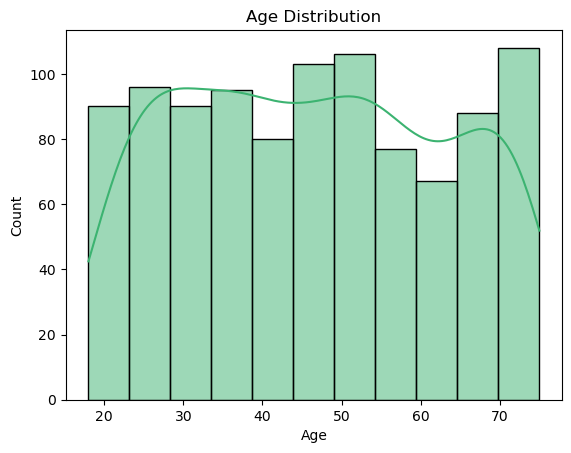

C:\Users\Vikash Rao\AppData\Local\Temp\ipykernel_9120\1353530302.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette="Set2")


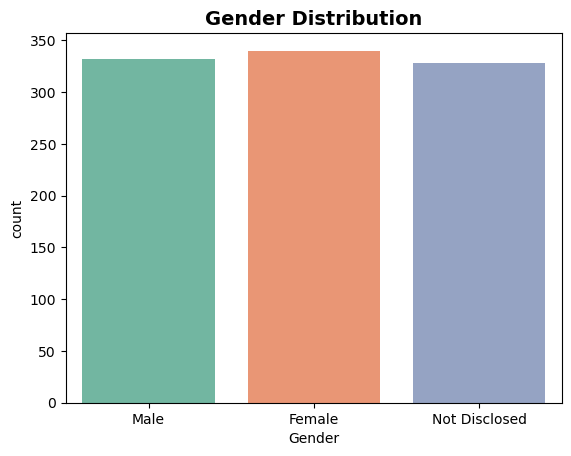

In [59]:
# Q1: What is the distribution of Age in the dataset?

print(df['Age'].describe())

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], kde=True, color="mediumseagreen")
plt.title("Age Distribution")
plt.show()

# how many count of gender distribution
sns.countplot(x='Gender', data=df, palette="Set2")
plt.title("Gender Distribution", fontsize=14, fontweight="bold")
plt.show()

# Merging

In [60]:
# why using the how=left

total_spend = transaction.groupby("CustomerID")["TransactionAmount"].sum().reset_index()

final = pd.merge(customers, total_spend, on="CustomerID", how="left")

In [61]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         1000 non-null   object        
 1   Name               1000 non-null   object        
 2   Email              1000 non-null   object        
 3   Gender             1000 non-null   object        
 4   Age                1000 non-null   int64         
 5   City               1000 non-null   object        
 6   MaritalStatus      1000 non-null   object        
 7   NumChildren        1000 non-null   int64         
 8   JoinDate           1000 non-null   datetime64[ns]
 9   TransactionAmount  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 78.3+ KB


In [62]:
customers.columns

Index(['CustomerID', 'Name', 'Email', 'Gender', 'Age', 'City', 'MaritalStatus',
       'NumChildren', 'JoinDate'],
      dtype='object')

In [63]:
transaction.columns

Index(['CustomerID', 'TransactionDate', 'TransactionAmount'], dtype='object')

In [64]:
final.columns

Index(['CustomerID', 'Name', 'Email', 'Gender', 'Age', 'City', 'MaritalStatus',
       'NumChildren', 'JoinDate', 'TransactionAmount'],
      dtype='object')

In [65]:
final[["CustomerID", "City", "TransactionAmount"]]

,CustomerID,City,TransactionAmount
0,CUST10000,Delhi,21265.49
1,CUST10001,Kolkata,28654.31
2,CUST10002,Kolkata,23884.03
3,CUST10003,Pune,24206.03
4,CUST10004,Delhi,25565.30
...,...,...,...
995,CUST10995,Hyderabad,24325.19
996,CUST10996,Delhi,21809.11
997,CUST10997,Ahmedabad,21120.48
998,CUST10998,Jaipur,29494.56


In [66]:
merged_df = pd.merge(transaction, customers, on="CustomerID", how="left")

In [67]:
merged_df.columns

Index(['CustomerID', 'TransactionDate', 'TransactionAmount', 'Name', 'Email',
       'Gender', 'Age', 'City', 'MaritalStatus', 'NumChildren', 'JoinDate'],
      dtype='object')

In [68]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   TransactionDate    23050 non-null  datetime64[ns]
 2   TransactionAmount  23050 non-null  float64       
 3   Name               23050 non-null  object        
 4   Email              23050 non-null  object        
 5   Gender             23050 non-null  object        
 6   Age                23050 non-null  int64         
 7   City               23050 non-null  object        
 8   MaritalStatus      23050 non-null  object        
 9   NumChildren        23050 non-null  int64         
 10  JoinDate           23050 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 1.9+ MB


In [69]:
merged_df.describe()

,TransactionDate,TransactionAmount,Age,NumChildren,JoinDate
count,23050,23050.000000,23050.000000,23050.000000,23050
mean,2024-01-22 02:29:03.618221312,1000.138814,46.390889,1.319610,2022-07-20 01:45:49.744034560
min,2020-08-22 00:00:00,3.870000,18.000000,0.000000,2020-07-29 00:00:00
25%,2023-05-07 00:00:00,482.107500,32.000000,0.000000,2021-07-10 00:00:00
50%,2024-04-21 00:00:00,844.755000,46.000000,1.000000,2022-07-02 00:00:00
75%,2024-12-12 00:00:00,1346.795000,60.000000,2.000000,2023-08-01 00:00:00
max,2025-07-29 00:00:00,6890.190000,75.000000,4.000000,2024-07-28 00:00:00
std,NaN,703.358978,16.562675,1.191471,NaN


In [70]:
merged_df.groupby(['CustomerID', 'TransactionAmount', 'Name', 'Gender', 'City']).size()

CustomerID  TransactionAmount  Name            Gender  City     
CUST10000   92.16              Onkar Bhargava  Male    Delhi        1
            194.10             Onkar Bhargava  Male    Delhi        1
            225.70             Onkar Bhargava  Male    Delhi        1
            467.93             Onkar Bhargava  Male    Delhi        1
            564.00             Onkar Bhargava  Male    Delhi        1
                                                                   ..
CUST10999   1619.39            Alia Sekhon     Male    Hyderabad    1
            1883.60            Alia Sekhon     Male    Hyderabad    1
            1948.48            Alia Sekhon     Male    Hyderabad    1
            1993.71            Alia Sekhon     Male    Hyderabad    1
            2539.21            Alia Sekhon     Male    Hyderabad    1
Length: 23050, dtype: int64

<div style="text-align:center;">

# RFM Analysis

</div>

# Recency

In [5]:
import pandas as pd
customers = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Master_Data.csv",encoding = "latin1")
transaction = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Transactions.csv",encoding = "latin1")

In [9]:
import datetime as dt

In [12]:
# Convert the column to datetime format first
transaction['TransactionDate'] = pd.to_datetime(transaction['TransactionDate'])

# Now this line will work perfectly
reference_date = transaction['TransactionDate'].max() + dt.timedelta(days=1)

In [13]:
reference_date

Timestamp('2025-07-30 00:00:00')

In [91]:
# RFM calculation
rfm = df_final.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,
    'CustomerID': 'count',
    'TransactionAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
CUST10000,12,23,21265.49
CUST10001,34,30,28654.31
CUST10002,17,24,23884.03
CUST10003,80,25,24206.03
CUST10004,7,19,25565.30


# Frequency

In [77]:
merged_df.groupby('CustomerID').size()

CustomerID
CUST10000    23
CUST10001    30
CUST10002    24
CUST10003    25
CUST10004    19
             ..
CUST10995    21
CUST10996    21
CUST10997    20
CUST10998    25
CUST10999    23
Length: 1000, dtype: int64

# Monetary

In [ ]:
final.groupby(["CustomerID", "Name", "TransactionAmount"]).size()

In [ ]:
transaction.columns

In [ ]:
df.columns = df.columns.str.strip()       # remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_")  # replace spaces with underscores
print(df.columns)


In [ ]:
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
else:
    print("Column 'TransactionDate' not found. Available columns:", df.columns)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# how to use inner join & left join

df_inner= pd.merge(transaction, customers, on="CustomerID", how="inner")
df_inner.info()

# Left Join
df_left= pd.merge(transaction, customers, on="CustomerID", how="left")
df_left.info()


In [ ]:
df = df.rename(columns={'TransactionDate': 'TransactionDate1'})


In [ ]:
customers = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Master_Data.csv",encoding = "latin1")
transaction = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Transactions.csv",encoding = "latin1")

In [87]:
df_final = pd.merge(customers, transaction, on='CustomerID')

In [88]:
# convert to datetime
df_final['TransactionDate'] = pd.to_datetime(df_final['TransactionDate'])

C:\Users\Vikash Rao\AppData\Local\Temp\ipykernel_9120\3082607708.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final['TransactionDate'] = pd.to_datetime(df_final['TransactionDate'])


In [90]:
# Reference date
reference_date = df_final['TransactionDate'].max()

In [92]:
# checking the with
%whos

Variable               Type         Data/Info
---------------------------------------------
customers              DataFrame    Shape: (1000, 9)
dataframe_columns      function     <function dataframe_colum<...>ns at 0x00000280244539C0>
dataframe_hash         function     <function dataframe_hash at 0x000002801F4DA660>
df                     DataFrame    Shape: (1000, 9)
df_final               DataFrame    Shape: (23050, 11)
dtypes_str             function     <function dtypes_str at 0x0000028017EA77E0>
final                  DataFrame    Shape: (1000, 10)
get_dataframes         function     <function get_dataframes at 0x000002801F4DBE20>
getpass                module       <module 'getpass' from 'C<...>conda3\\Lib\\getpass.py'>
hashlib                module       <module 'hashlib' from 'C<...>conda3\\Lib\\hashlib.py'>
import_pandas_safely   function     <function import_pandas_s<...>ly at 0x000002801F4D9BC0>
is_data_frame          function     <function is_data_frame at 0x000002802445

# Create RFM Scores (1–5)

In [96]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [97]:
# 🧩 Step 4: Combine RFM Scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
CUST10000,12,23,21265.49,4,3,2,432
CUST10001,34,30,28654.31,3,5,5,355
CUST10002,17,24,23884.03,4,3,3,433
CUST10003,80,25,24206.03,1,4,3,143
CUST10004,7,19,25565.30,5,1,4,514


In [98]:
# 🏷️ Step 5: Customer Segments
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4:
        return 'Recent Customers'
    elif row['F_Score'] >= 4:
        return 'Frequent Customers'
    elif row['M_Score'] >= 4:
        return 'Big Spenders'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# 📊 : Segment Distribution

<Axes: title={'center': 'Customer Segments'}, xlabel='Segment'>

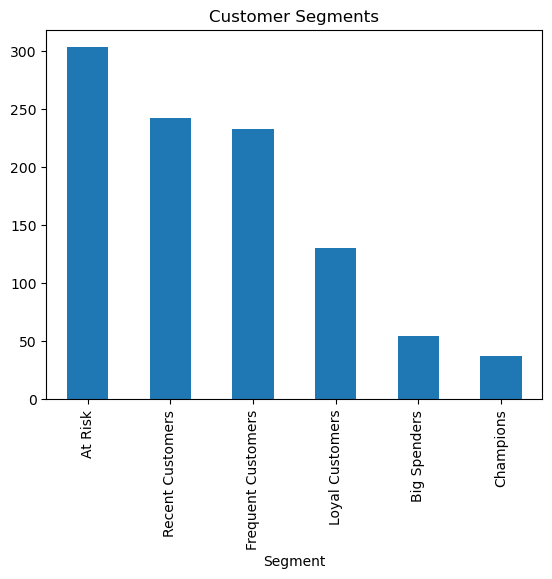

In [99]:
rfm['Segment'].value_counts().plot(kind='bar', title='Customer Segments')

# 🎨 Improved Customer Segments Chart (Seaborn)

C:\Users\Vikash Rao\AppData\Local\Temp\ipykernel_9120\63965389.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


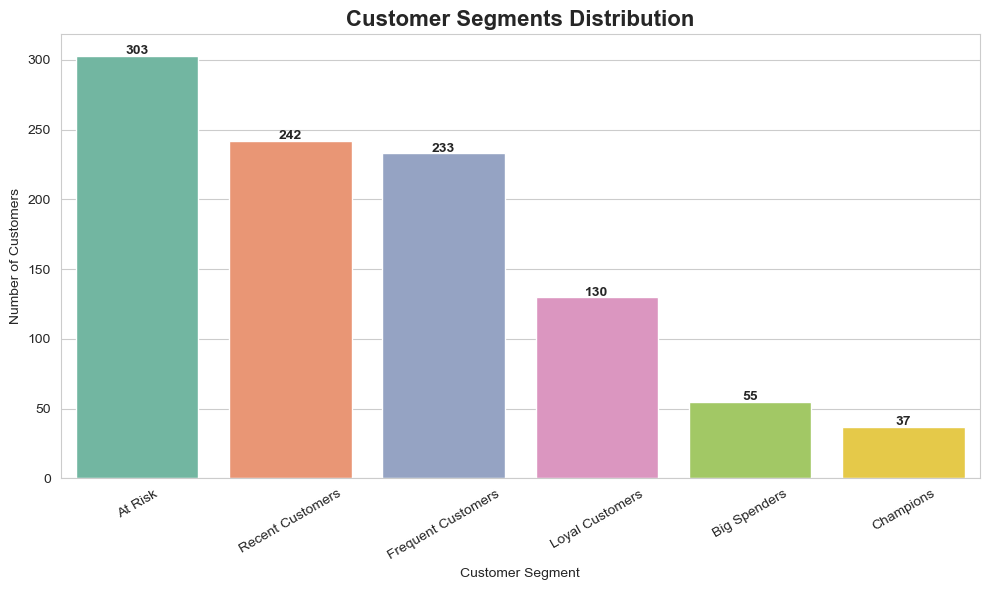

In [100]:
# Prepare data
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Barplot
ax = sns.barplot(
    x='Segment',
    y='Count',
    data=segment_counts,
    palette='Set2'
)

# Add value labels
for i, v in enumerate(segment_counts['Count']):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

# Titles and labels
plt.title('Customer Segments Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

# Rotate labels for better readability
plt.xticks(rotation=30)

# Layout
plt.tight_layout()

plt.show()

- Key Business Segments
- Champions → Best customers (high R, F, M)
- Loyal Customers → Frequent buyers
- Recent Customers → New but active
- Big Spenders → High value
- At Risk → Need attention

# 💰 Customer Total Spending

In [105]:
if 'Customer_ID' in df.columns and 'Amount' in df.columns:
    customer_spending = df.groupby('Customer_ID')['Amount'].sum().reset_index()
    customer_spending.rename(columns={'Amount': 'Total_Spending'}, inplace=True)
else:
    print("Available columns:", df.columns)


Available columns: Index(['CustomerID', 'Name', 'Email', 'Gender', 'Age', 'City', 'MaritalStatus',
       'NumChildren', 'JoinDate'],
      dtype='object')


In [107]:
# Total Revenue
total_revenue = df_final['TransactionAmount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 23053199.660000004


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='TransactionDate'>

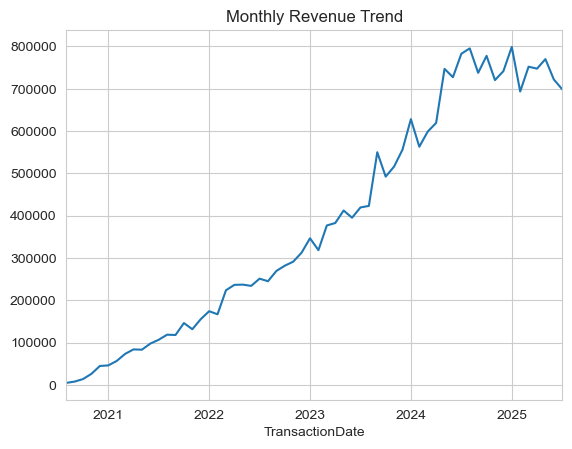

In [108]:
monthly_sales = df_final.groupby(df_final['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum()

monthly_sales.plot(kind='line', title='Monthly Revenue Trend')

# 🔹 6. Data Visualization
📊 1. Sales Distribution

In [111]:
customers.columns

Index(['CustomerID', 'Name', 'Email', 'Gender', 'Age', 'City', 'MaritalStatus',
       'NumChildren', 'JoinDate'],
      dtype='object')

In [13]:
transaction.columns

Index(['CustomerID', 'TransactionDate', 'TransactionAmount'], dtype='object')

# Create Useful Features (Real Analysis)

In [20]:
customers = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Master_Data.csv",encoding = "latin1")
transaction = pd.read_csv(r"C:\Users\Vikash Rao\python 0.7\Customer_Transactions.csv",encoding = "latin1")

In [24]:
# Merge
df = pd.merge(customers, transaction, on='CustomerID')

# Spending
customer_spending = df.groupby('CustomerID')['TransactionAmount'].sum().reset_index()
customer_spending.rename(columns={'TransactionAmount': 'Total_Spending'}, inplace=True)

# Top customers
top_customers = customer_spending.sort_values(by='Total_Spending', ascending=False).head(10)

print(top_customers)

    CustomerID  Total_Spending
944  CUST10944        44784.99
510  CUST10510        44367.33
53   CUST10053        41674.56
776  CUST10776        41050.76
696  CUST10696        40035.48
671  CUST10671        39763.52
477  CUST10477        38015.78
196  CUST10196        37738.94
187  CUST10187        37627.78
413  CUST10413        37479.39


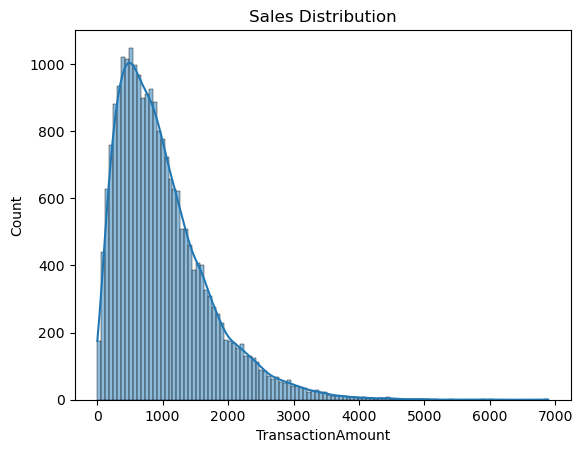

In [25]:
# Sales Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(df['TransactionAmount'], kde=True)
plt.title("Sales Distribution")
plt.show()

# Top Customers

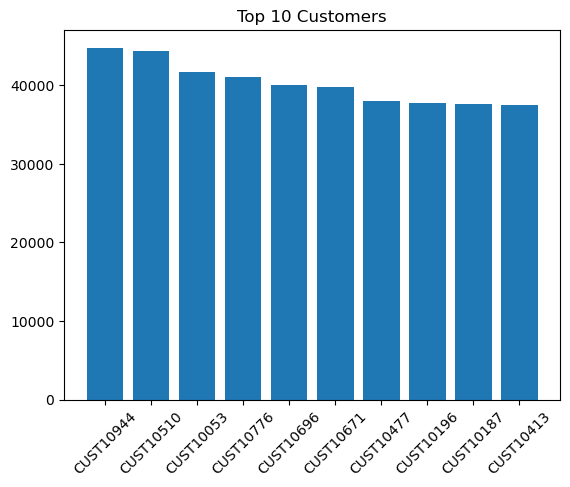

In [26]:
customer_spending = df.groupby('CustomerID')['TransactionAmount'].sum().reset_index()

top_customers = customer_spending.sort_values(by='TransactionAmount', ascending=False).head(10)

plt.figure()
plt.bar(top_customers['CustomerID'], top_customers['TransactionAmount'])
plt.title("Top 10 Customers")
plt.xticks(rotation=45)
plt.show()

# City-wise Revenue

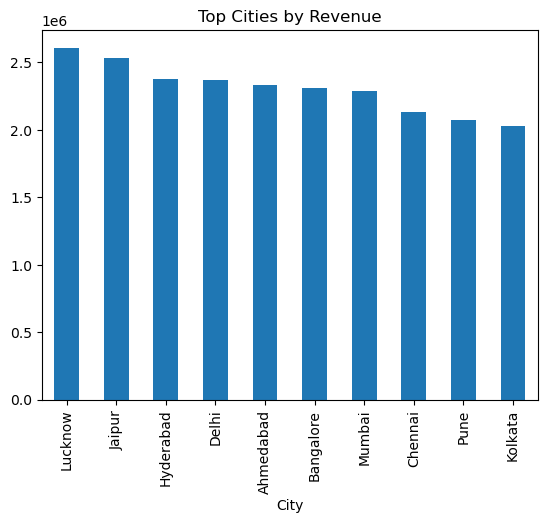

In [27]:
city_sales = df.groupby('City')['TransactionAmount'].sum().sort_values(ascending=False)

city_sales.head(10).plot(kind='bar')
plt.title("Top Cities by Revenue")
plt.show()

# Age Group Analysis

In [37]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 80],
    labels=['18-30', '31-45', '46-60', '60+']
)

In [38]:
age_sales = df.groupby('Age_Group')['TransactionAmount'].sum()

C:\Users\Vikash Rao\AppData\Local\Temp\ipykernel_2920\2833841.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age_Group')['TransactionAmount'].sum()


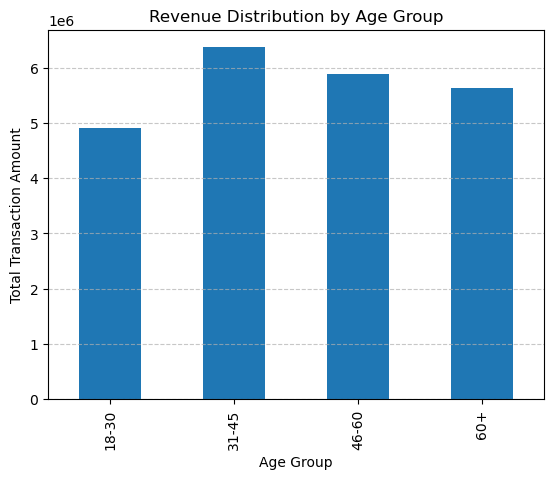

In [40]:
plt.figure()

age_sales.sort_index().plot(kind='bar')

plt.title("Revenue Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Transaction Amount")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Gender-wise Revenue

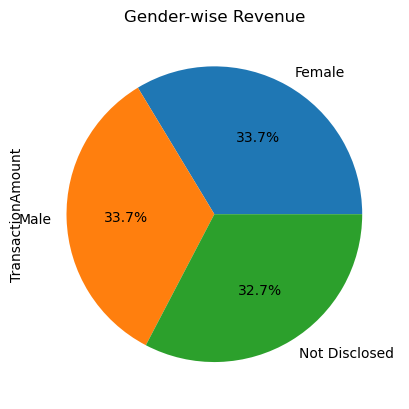

In [34]:
gender_sales = df.groupby('Gender')['TransactionAmount'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender-wise Revenue")
plt.show()

# Correlation Heatmap

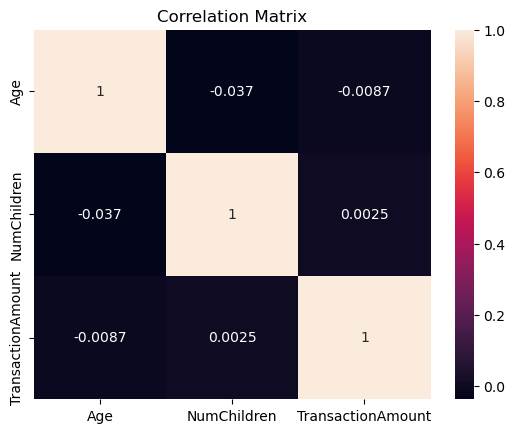

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Business Insights

## Champions
- These customers purchase frequently and spend the highest amount.
- Should receive loyalty rewards and premium offers.
### Loyal Customers
- Strong repeat buyers.
- Good target for cross-selling and membership plans.
#### At Risk Customers
- Previously active customers becoming inactive.
- Re-engagement campaigns should be launched.
##### Lost Customers
- Very low engagement.
- Low ROI marketing recommended.
###### Big Spenders
- High monetary contribution despite lower purchase frequency.
- Personalized premium campaigns can improve retention.

# Final Conclusion

# Conclusion

The project successfully analyzed customer behavior using demographic analysis and RFM segmentation.

Key findings:
- A small group of customers contributes major revenue.
- Champions and Loyal Customers are crucial for retention strategies.
- At-Risk customers require immediate engagement campaigns.
- Demographic patterns can improve targeted marketing.

The analysis can help the company improve customer retention, marketing efficiency, and revenue generation.

In [1]:
print("Project Completed Successfully ✅")

Project Completed Successfully ✅
